In [27]:
# Basic setup
!pip install -q tensorflow matplotlib pandas scikit-learn

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile


from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate
from tensorflow.keras.models import Model


import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc,classification_report
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Unzip your image datasets
for zip_file in ['train.zip', 'val.zip', 'test.zip']:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(os.path.splitext(zip_file)[0])


In [3]:
# Load metadata CSVs
train_meta = pd.read_csv('metadata/train_augmented_metadata.csv')
val_meta = pd.read_csv('metadata/val_metadata.csv')
test_meta = pd.read_csv('metadata/test_metadata.csv')

train_meta.head()


,photo_id,business_id,caption,label
0,--DqlLaO1I0D7uFgvRInww_aug,0wRkPZNnBEHMqHGqMfdIYA,They renovated the Taco Bell! It's the little...,outside
1,-03jEudW-0CXZhRhY9j3cg_aug,2C1woaOBpUC2iEpvKx96gg,NaN,drink
2,-194bfBI_zM5ELv-mizqvA_aug,Tf_Oj8uWRvXmqkEmntzTdA,NaN,inside
3,-174ci6bCbX7-D0khhO7hg_aug,DKJrr6qa4mzeyJTBCA2Sqw,Italian Hoagie,food
4,--IHD2ZgFPfFMR4qMkLzFA_aug,3qpubK1C8SsDcq8BeKOEbA,Hidden in the rear is this oasis-like beer gar...,outside


In [ ]:
import os
import pandas as pd
from shutil import copy2

def organize_images(csv_path, image_dir, output_dir):
    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        photo_id = str(row['photo_id'])
        label = str(row['label'])

        # Source image path (your unzipped image dir will be "train/train", "val/val", etc.)
        src_path = os.path.join(image_dir, f"{photo_id}.jpg")

        # Destination path: data_sorted/train/label/photo_id.jpg
        dst_folder = os.path.join(output_dir, label)
        dst_path = os.path.join(dst_folder, f"{photo_id}.jpg")

        os.makedirs(dst_folder, exist_ok=True)

        if os.path.exists(src_path):
            copy2(src_path, dst_path)
        else:
            print(f"WARNING: {src_path} not found!")

# Root folder 
image_root = ""

# Paths to metadata files
meta_paths = {
    'train': 'metadata/train_augmented_metadata.csv',
    'val': 'metadata/val_metadata.csv',
    'test': 'metadata/test_metadata.csv'
}

# Process each split
for split, csv_file in meta_paths.items():
    print(f"Processing {split} set...")

    image_dir = os.path.join(split, split)  # 'train/train', 'val/val', 'test/test'
    output_dir = os.path.join("data_sorted", split)

    organize_images(
        csv_path=csv_file,
        image_dir=image_dir,
        output_dir=output_dir
    )

print("Done organizing all splits.")


Processing train set...
Processing val set...
Processing test set...
✅ Done organizing all splits.


In [5]:
for root, dirs, files in os.walk("data_sorted/train"):
    print(f"{root} - {len(files)} files")


data_sorted/train - 0 files
data_sorted/train/outside - 4001 files
data_sorted/train/drink - 3971 files
data_sorted/train/food - 4006 files
data_sorted/train/menu - 1191 files
data_sorted/train/inside - 4023 files


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (128, 128)
batch_size = 32

# Image generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'data_sorted/train',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    'data_sorted/val',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 17192 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


In [ ]:
#train and validation metadata
train_meta = pd.read_csv("metadata/train_augmented_metadata.csv")
val_meta = pd.read_csv("metadata/val_metadata.csv")

train_meta.head()

,photo_id,business_id,caption,label
0,--DqlLaO1I0D7uFgvRInww_aug,0wRkPZNnBEHMqHGqMfdIYA,They renovated the Taco Bell! It's the little...,outside
1,-03jEudW-0CXZhRhY9j3cg_aug,2C1woaOBpUC2iEpvKx96gg,NaN,drink
2,-194bfBI_zM5ELv-mizqvA_aug,Tf_Oj8uWRvXmqkEmntzTdA,NaN,inside
3,-174ci6bCbX7-D0khhO7hg_aug,DKJrr6qa4mzeyJTBCA2Sqw,Italian Hoagie,food
4,--IHD2ZgFPfFMR4qMkLzFA_aug,3qpubK1C8SsDcq8BeKOEbA,Hidden in the rear is this oasis-like beer gar...,outside


In [8]:
train_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17192 entries, 0 to 17191
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   photo_id     17192 non-null  object
 1   business_id  17192 non-null  object
 2   caption      8227 non-null   object
 3   label        17192 non-null  object
dtypes: object(4)
memory usage: 537.4+ KB


In [ ]:
# replacing NaN with empty string
train_meta['caption'] = train_meta['caption'].fillna('')
val_meta['caption'] = val_meta['caption'].fillna('')

# Feature 1: Length of caption 
train_meta['caption_length'] = train_meta['caption'].apply(len)
val_meta['caption_length'] = val_meta['caption'].apply(len)

# Feature 2: Number of words in caption
train_meta['caption_word_count'] = train_meta['caption'].apply(lambda x: len(x.split()))
val_meta['caption_word_count'] = val_meta['caption'].apply(lambda x: len(x.split()))


train_meta[['caption', 'caption_length', 'caption_word_count']].head()


,caption,caption_length,caption_word_count
0,They renovated the Taco Bell! It's the little...,62,11
1,,0,0
2,,0,0
3,Italian Hoagie,14,2
4,Hidden in the rear is this oasis-like beer gar...,65,12


In [ ]:
import numpy as np
from tensorflow.keras.utils import Sequence
import os

class ImageMetadataGenerator(Sequence):
    def __init__(self, image_generator, metadata_df, batch_size, image_dir, **kwargs):
        super().__init__(**kwargs)
        self.image_generator = image_generator
        self.metadata_df = metadata_df
        self.batch_size = batch_size
        self.image_dir = image_dir

        
        self.metadata_map = self._prepare_metadata_map()

    def _prepare_metadata_map(self):
        mapping = {}
        for i, row in self.metadata_df.iterrows():
            filename = row['photo_id'] + ".jpg"
            mapping[filename] = np.array([
                row['caption_length'],
                row['caption_word_count']
            ], dtype='float32')
        return mapping

    def __len__(self):
        return len(self.image_generator)

    def __getitem__(self, index):
        images, labels = self.image_generator[index]
        metadata_batch = []

        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.image_generator.filenames))
        batch_filenames = [
            os.path.basename(self.image_generator.filenames[i])
            for i in range(start_idx, end_idx)
        ]

        for fname in batch_filenames:
            meta_vec = self.metadata_map.get(fname, np.zeros(2))  
            metadata_batch.append(meta_vec)

        return (images, np.array(metadata_batch)), labels


Train and validation generators

In [ ]:
#train metadata generator
train_meta_gen = ImageMetadataGenerator(
    image_generator=train_gen,
    metadata_df=train_meta,
    batch_size=batch_size,
    image_dir='data_sorted/train'
)

#validation metadata generator
val_meta_gen = ImageMetadataGenerator(
    image_generator=val_gen,
    metadata_df=val_meta,
    batch_size=batch_size,
    image_dir='data_sorted/val'
)


Test generator

In [ ]:
# Load test metadata
test_meta = pd.read_csv("metadata/test_metadata.csv")
test_meta['caption'] = test_meta['caption'].fillna('')
test_meta['caption_length'] = test_meta['caption'].apply(len)
test_meta['caption_word_count'] = test_meta['caption'].apply(lambda x: len(x.split()))


test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'data_sorted/test',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # do not shuffle!
)


test_meta_gen = ImageMetadataGenerator(
    image_generator=test_gen,
    metadata_df=test_meta,
    batch_size=batch_size,
    image_dir='data_sorted/test'
)


Found 2149 images belonging to 5 classes.


In [14]:
vgg_full = VGG16(weights='imagenet', include_top=True)
vgg_full.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


# Image input
image_input = Input(shape=(128, 128, 3), name='image_input')

# VGG16 base model 
vgg_base = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)

# feature extraction phase
for layer in vgg_base.layers:
    layer.trainable = False

# VGG16 output
x = Flatten()(vgg_base.output)

# Metadata input 
metadata_input = Input(shape=(2,), name='metadata_input')


metadata_dense = Dense(16, activation='relu')(metadata_input)

# image and metadata features
combined = Concatenate()([x, metadata_dense])

# Dense layers 
combined = Dense(256, activation='relu')(combined)
combined = Dense(128, activation='relu')(combined)

# Output layer
output = Dense(5, activation='softmax')(combined)

# Final model
model = Model(inputs=[image_input, metadata_input], outputs=output)


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ image_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 16,849,781 (64.28 MB)

 Trainable params: 2,135,093 (8.14 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [17]:
#
steps_per_epoch = len(train_meta_gen)
validation_steps = len(val_meta_gen)


history = model.fit(
    train_meta_gen,
    validation_data=val_meta_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=10,
    verbose=1
)


Epoch 1/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.8157 - loss: 0.4899 - val_accuracy: 0.8285 - val_loss: 0.4666
Epoch 2/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.8735 - loss: 0.3407 - val_accuracy: 0.8295 - val_loss: 0.4820
Epoch 3/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.8943 - loss: 0.2780 - val_accuracy: 0.8099 - val_loss: 0.5491
Epoch 4/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9228 - loss: 0.2064 - val_accuracy: 0.8211 - val_loss: 0.5418
Epoch 5/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9449 - loss: 0.1488 - val_accuracy: 0.8127 - val_loss: 0.6659
Epoch 6/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9552 - loss: 0.1176 - val_accuracy: 0.8183 - val_loss: 0.6433
Epoch 7/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9623 - loss: 0.0978 - val_accuracy: 0.8322 - val_loss: 0.7326
Epoch 8/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.9741 - loss: 0.0684 - 

In [ ]:
# "fine-tuning the entire model"

from tensorflow.keras.optimizers import Adam

for layer in vgg_base.layers:
    layer.trainable = True


model.compile(
    optimizer=Adam(learning_rate=1e-5),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


print("Trainable layers:")
for layer in model.layers:
    print(layer.name, layer.trainable)


model.summary()



Trainable layers:
image_input True
block1_conv1 True
block1_conv2 True
block1_pool True
block2_conv1 True
block2_conv2 True
block2_pool True
block3_conv1 True
block3_conv2 True
block3_conv3 True
block3_pool True
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True
metadata_input True
flatten True
dense True
concatenate True
dense_1 True
dense_2 True
dense_3 True


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ image_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 16,849,781 (64.28 MB)

 Trainable params: 16,849,781 (64.28 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train again (fine-tuning phase)
history_finetune = model.fit(
    train_meta_gen,
    validation_data=val_meta_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=10,  # adjust as needed
    verbose=1
)

Epoch 1/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 143s 218ms/step - accuracy: 0.9718 - loss: 0.0808 - val_accuracy: 0.8341 - val_loss: 0.7984
Epoch 2/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 106s 190ms/step - accuracy: 0.9881 - loss: 0.0346 - val_accuracy: 0.8267 - val_loss: 0.8875
Epoch 3/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 102s 190ms/step - accuracy: 0.9892 - loss: 0.0347 - val_accuracy: 0.8448 - val_loss: 0.7836
Epoch 4/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 142s 190ms/step - accuracy: 0.9907 - loss: 0.0265 - val_accuracy: 0.8430 - val_loss: 0.9068
Epoch 5/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 103s 191ms/step - accuracy: 0.9958 - loss: 0.0135 - val_accuracy: 0.8509 - val_loss: 0.8091
Epoch 6/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 141s 190ms/step - accuracy: 0.9897 - loss: 0.0349 - val_accuracy: 0.8523 - val_loss: 0.7488
Epoch 7/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 143s 191ms/step - accuracy: 0.9951 - loss: 0.0146 - val_accuracy: 0.8621 - val_loss: 0.8162
Epoch 8/10
538/538 ━━━━━━━━━━━━━━━━━━━━ 142s 191ms/step - accuracy: 0.9937 -

In [20]:
model.save('VGG16_with_metadata1.keras')

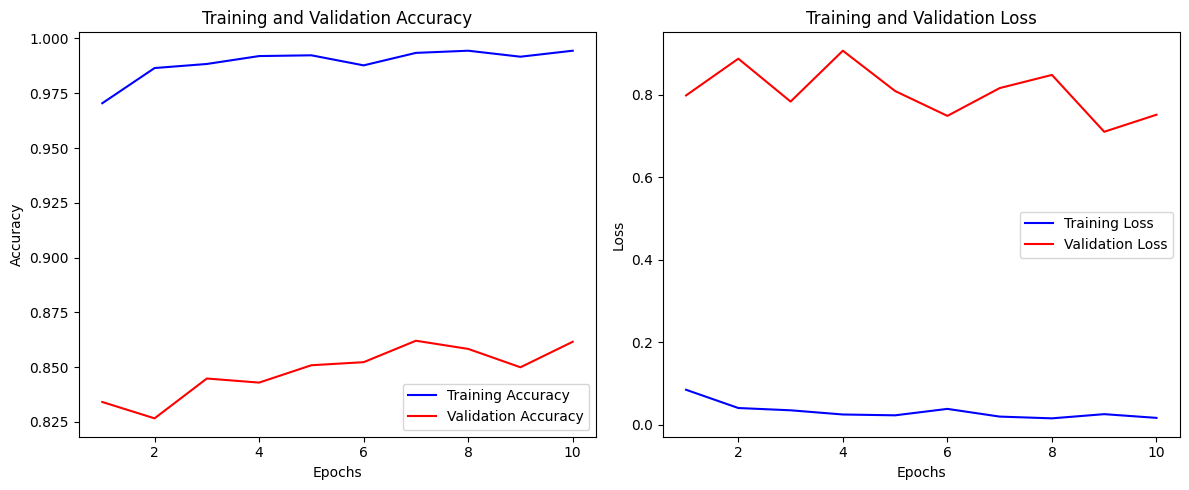

In [22]:
import matplotlib.pyplot as plt


acc     = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']
loss     = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']
epochs   = range(1, len(acc) + 1)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def evaluate_model(model, test_gen, num_classes=5, class_names=None):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

    # class labels
    if class_names is None:
        if hasattr(test_gen, 'class_indices'):
            class_names = list(test_gen.class_indices.keys())
            print(f"Auto-detected class names: {class_names}")
        elif hasattr(test_gen, 'image_generator') and hasattr(test_gen.image_generator, 'class_indices'):
            class_names = list(test_gen.image_generator.class_indices.keys())
            print(f"Auto-detected class names from image_generator: {class_names}")
        else:
            print(" Could not auto-detect class names.")



   
    steps = len(test_gen)


    y_true = []
    y_pred_probs = []

    for i in range(steps):
        (images, metadata), labels = test_gen[i]

        # probabilities
        preds = model.predict([images, metadata], verbose=0)
        y_pred_probs.extend(preds)
        y_true.extend(labels)

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)

    
    y_true_classes = np.argmax(y_true, axis=1)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Accuracy
    acc = accuracy_score(y_true_classes, y_pred_classes)
    print(f'Accuracy: {acc:.4f}')

    # AUC
    try:
        auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
        print(f'AUC (OvR): {auc_score:.4f}')
    except Exception as e:
        print("AUC calculation failed:", e)
        auc_score = None

    # Confusion matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names if class_names else range(num_classes),
                yticklabels=class_names if class_names else range(num_classes))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Classification report
    print("Classification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names if class_names else None))

    # ROC curves (one vs rest)
    plt.figure(figsize=(10,8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_names[i] if class_names else i} (AUC = {roc_auc:.2f})')

    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    
    return {
        'accuracy': acc,
        'auc': auc_score,
        'confusion_matrix': cm
    }


[INFO] Auto-detected class names from image_generator: ['drink', 'food', 'inside', 'menu', 'outside']
Accuracy: 0.8616
AUC (OvR): 0.9803


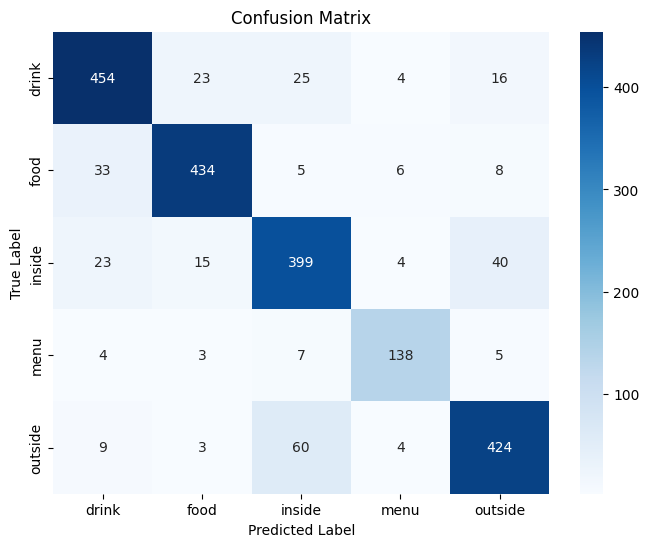

Classification Report:
              precision    recall  f1-score   support

       drink       0.87      0.87      0.87       522
        food       0.91      0.89      0.90       486
      inside       0.80      0.83      0.82       481
        menu       0.88      0.88      0.88       157
     outside       0.86      0.85      0.85       500

    accuracy                           0.86      2146
   macro avg       0.87      0.86      0.86      2146
weighted avg       0.86      0.86      0.86      2146



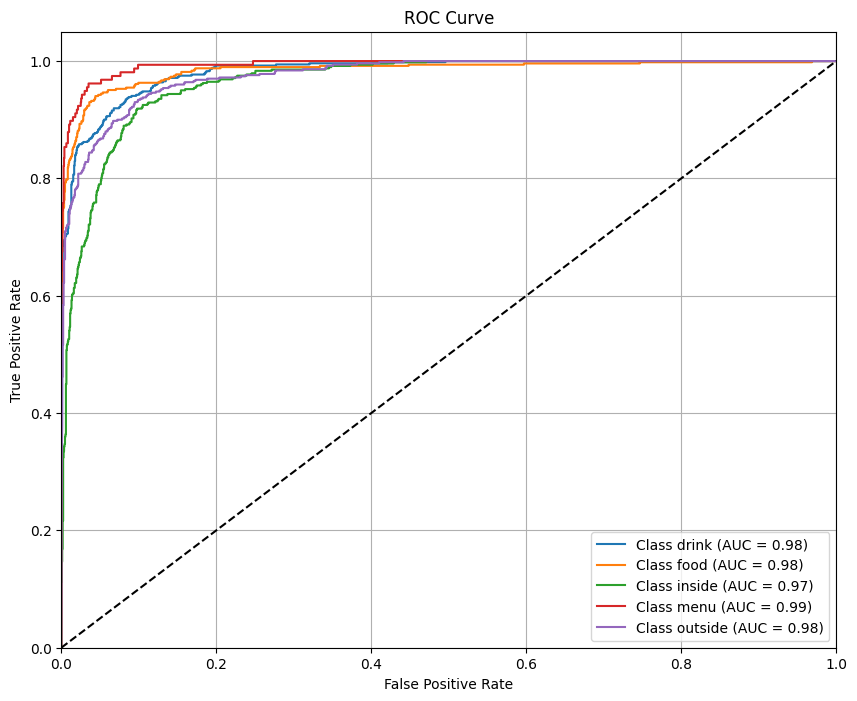

In [47]:

metrics = evaluate_model(model, val_meta_gen, num_classes=5)


[INFO] Auto-detected class names from image_generator: ['drink', 'food', 'inside', 'menu', 'outside']
Accuracy: 0.9991
AUC (OvR): 1.0000


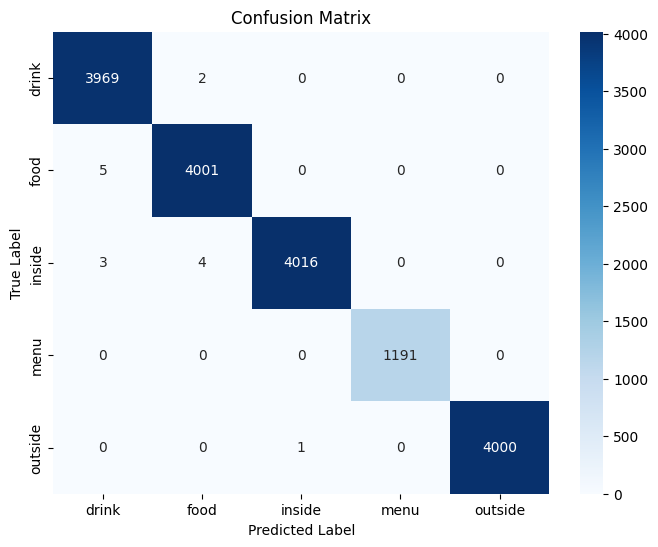

Classification Report:
              precision    recall  f1-score   support

       drink       1.00      1.00      1.00      3971
        food       1.00      1.00      1.00      4006
      inside       1.00      1.00      1.00      4023
        menu       1.00      1.00      1.00      1191
     outside       1.00      1.00      1.00      4001

    accuracy                           1.00     17192
   macro avg       1.00      1.00      1.00     17192
weighted avg       1.00      1.00      1.00     17192



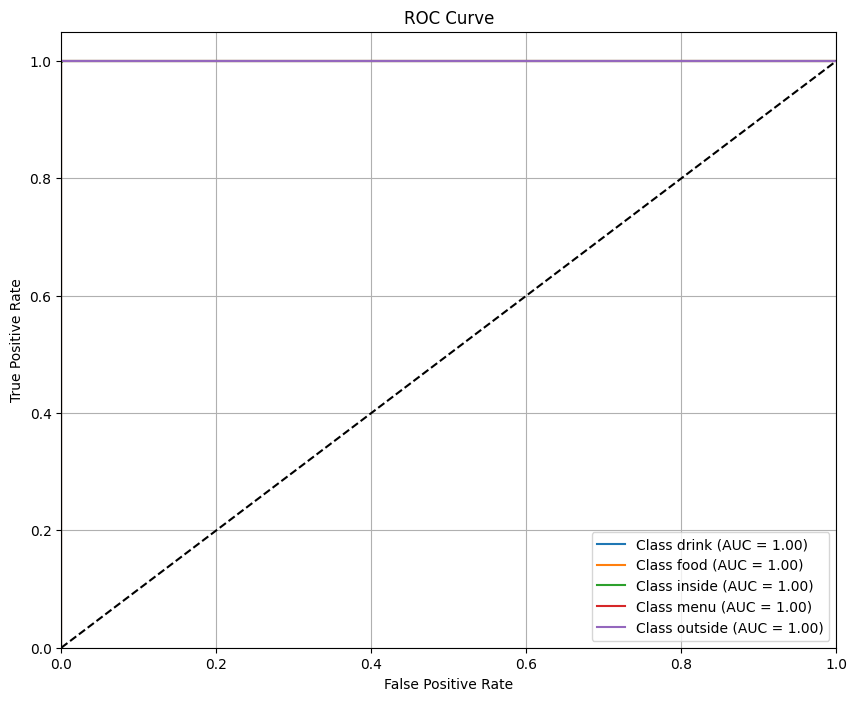

In [43]:
metrics = evaluate_model(model, train_meta_gen, num_classes=5)

# Function to track Results

In [45]:

results_df = pd.DataFrame(columns=['Model', 'Data Type', 'Accuracy', 'AUC'])


def log_model_results(model_name, data_type, accuracy, auc_score):
    global results_df
    new_entry = {
        'Model': model_name,
        'Data Type': data_type,
        'Accuracy': accuracy,
        'AUC': auc_score
    }
    results_df = pd.concat([results_df, pd.DataFrame([new_entry])], ignore_index=True)
    print(f"[INFO] Logged results for {model_name} ({data_type})")


In [48]:
log_model_results(
    model_name = 'VGG16 + metadata (fine-tuned)',
    data_type = 'Validation',
    accuracy = metrics['accuracy'],
    auc_score = metrics['auc']
)


[INFO] Logged results for VGG16 + metadata (fine-tuned) (Validation)


Train Accuracy - 99%, Validation Accuracy - 86%

1. possible overfitting might be because of small dataset and powerful model as I am training all layers.

Next Steps:

1. Reduce overfitting and adding better features on top.
2. Adding regularization, drop out, removing dense layers.